In [ ]:
!pip install unsloth transformers trl datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 129.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 868.6/868.6 kB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 106.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 117.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 116.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

In [ ]:
import torch
from unsloth import FastLanguageModel
from datasets import load_dataset
from trl import SFTTrainer

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [ ]:
base_model , tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Qwen2.5-7B-Instruct",
    load_in_4bit = True,
    max_seq_length = 2048,
    use_gradient_checkpointing = "unsloth",

)

==((====))==  Unsloth 2026.5.5: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/qwen2.5-7b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


In [ ]:

model = FastLanguageModel.get_peft_model(
    base_model,
    r=8,
    lora_alpha = 16,
    bias="none",
    target_modules = ["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"]
)

Unsloth 2026.5.5 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


In [ ]:
from unsloth.chat_templates import get_chat_template,standardize_sharegpt

In [ ]:
tokenizer = get_chat_template(tokenizer, chat_template = "qwen-2.5")

In [ ]:
dataset = load_dataset("microsoft/orca-math-word-problems-200k",split = "train[:100000]")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/84.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/200035 [00:00<?, ? examples/s]

In [ ]:
type(dataset)

datasets.arrow_dataset.Dataset

In [ ]:
dataset[0]

{'question': 'Jungkook is the 5th place. Find the number of people who crossed the finish line faster than Jungkook.',
 'answer': 'If Jungkook is in 5th place, then 4 people crossed the finish line faster than him.'}

In [ ]:
dataset = standardize_sharegpt(dataset)

In [ ]:
dataset[:100]

### Mapping the Orca-Math dataset to Chat Format
The current dataset has `question` and `answer` keys. We need to convert these into a list of messages so the `tokenizer` can apply the chat template.

In [ ]:
def map_to_conversations(examples):
    questions = examples["question"]
    answers = examples["answer"]
    conversations = [
        [
            {"from": "human", "value": q},
            {"from": "gpt", "value": a}
        ]
        for q, a in zip(questions, answers)
    ]
    return {"conversations": conversations}

dataset = dataset.map(map_to_conversations, batched=True)

# Now apply the formatting function we defined earlier
dataset = dataset.map(formatting_prompts_func, batched=True)

print("Sample formatted text:")
print(dataset[0]["text"])

Map:   0%|          | 0/100000 [00:00<?, ? examples/s]

Map:   0%|          | 0/100000 [00:00<?, ? examples/s]

Sample formatted text:
<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>



### Applying the Chat Template
Since you are using an Instruct model, you need to format the data using the correct chat template so the model recognizes the instructions. We can use the `get_chat_template` utility from Unsloth.

In [ ]:
from unsloth.chat_templates import get_chat_template

tokenizer = get_chat_template(
    tokenizer,
    chat_template = "qwen-2.5", # Or "chatml"
    mapping = {"role" : "from", "content" : "value", "user" : "human", "assistant" : "gpt"},
)

def formatting_prompts_func(examples):
    convos = examples["conversations"]
    texts = [tokenizer.apply_chat_template(convo, tokenize = False, add_generation_prompt = False) for convo in convos]
    return { "text" : texts, }

print("Chat template applied successfully.")

Chat template applied successfully.


In [ ]:
dataset[0]

{'question': 'Jungkook is the 5th place. Find the number of people who crossed the finish line faster than Jungkook.',
 'answer': 'If Jungkook is in 5th place, then 4 people crossed the finish line faster than him.',
 'conversations': [{'from': 'human',
   'value': 'Jungkook is the 5th place. Find the number of people who crossed the finish line faster than Jungkook.'},
  {'from': 'gpt',
   'value': 'If Jungkook is in 5th place, then 4 people crossed the finish line faster than him.'}],
 'text': '<|im_start|>system\nYou are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>\n'}

In [ ]:
import transformers
from trl import SFTTrainer
from transformers import TrainingArguments

trainer = SFTTrainer(
    model = model,
    train_dataset = dataset,
    dataset_text_field = "text", # Fixed: points to the formatted string
    max_seq_length = 2048,
    tokenizer = tokenizer,
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        max_steps = 60,
        learning_rate = 2e-4,
        fp16 = not torch.cuda.is_bf16_supported(),
        bf16 = torch.cuda.is_bf16_supported(),
        logging_steps = 1,
        optim = "paged_adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
    ),
)

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/100000 [00:00<?, ? examples/s]

In [ ]:
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 100,000 | Num Epochs = 1 | Total steps = 60
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 20,185,088 of 7,635,801,600 (0.26% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss
1,4.099460
2,4.099460
3,3.779014
4,2.926526
5,2.276953
6,1.684125
7,1.217961
8,0.890606
9,0.685779
10,0.503247


Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-60/tokenizer_config.json.


TrainOutput(global_step=60, training_loss=0.3769528118199863, metrics={'train_runtime': 134.1122, 'train_samples_per_second': 3.579, 'train_steps_per_second': 0.447, 'total_flos': 428851839467520.0, 'train_loss': 0.3769528118199863, 'epoch': 0.0048})

### Visualizing Training Loss
Let's plot the training loss to see if the model is converging properly.

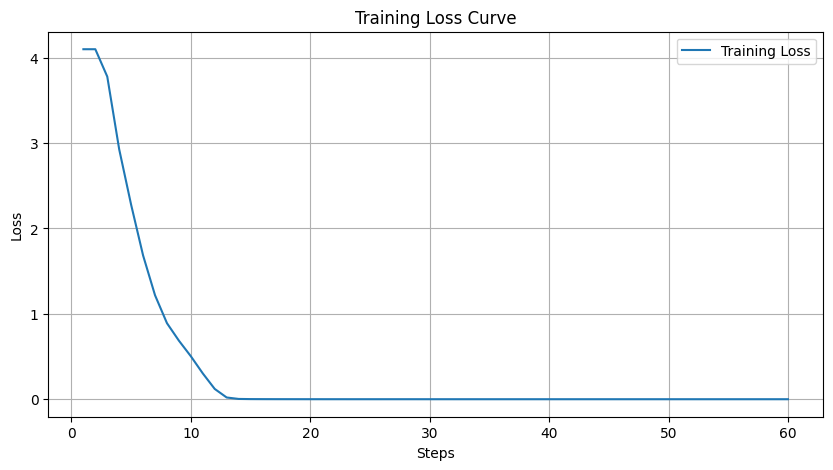

In [ ]:
import matplotlib.pyplot as plt

# Extract log history
history = trainer.state.log_history
training_loss = [x['loss'] for x in history if 'loss' in x]
steps = [x['step'] for x in history if 'loss' in x]

plt.figure(figsize=(10, 5))
plt.plot(steps, training_loss, label='Training Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from peft import PeftModel
modelFinetuned = PeftModel.from_pretrained(base_model, "/content/outputs/checkpoint-60")

/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


In [ ]:
model.save_pretrained("modelFinetuned")

In [ ]:
import warnings
# Suppress future and user warnings from transformers/peft libraries
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

from unsloth import FastLanguageModel
from peft import PeftModel
import torch
from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt=True, skip_special_tokens=True)

# Ensure the model is loaded
if 'modelFinetuned' not in locals():
    print("Loading fine-tuned model...")
    modelFinetuned = PeftModel.from_pretrained(base_model, "/content/outputs/checkpoint-60")

# 1. Prepare for inference
FastLanguageModel.for_inference(modelFinetuned)

# 2. Define the questions
questions = [
    "A number divided by 10 is 6. Yoongi got the result by subtracting 15 from a certain number. What is the result he got?",
    "What is the difference between the largest number and the smallest number that can be made by selecting four from the number magnets 2, 0, 3, 5, and 8 and arranging them in a row to form a four-digit number?"
]

for prompt in questions:
    print(f"\n--- Question: {prompt} ---\n")
    messages = [
        {"role": "user", "content": prompt},
    ]
    inputs = tokenizer.apply_chat_template(
        messages,
        tokenize = True,
        add_generation_prompt = True,
        return_tensors = "pt",
    ).to("cuda")

    # 4. Generate the response
    outputs = modelFinetuned.generate(
        input_ids = inputs,
        streamer = text_streamer,
        do_sample = True,
        max_new_tokens = 512,
        use_cache = True,
        temperature = 1.0,
        top_p = 0.9
    )

    # 5. Decode and display
    response = tokenizer.batch_decode(outputs)
    final_text = response[0].split("<|im_start|>assistant\n")[-1].replace("<|im_end|>", "")
    print(f"\nFinal Result: {final_text}")

Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- Question: A number divided by 10 is 6. Yoongi got the result by subtracting 15 from a certain number. What is the result he got? ---

Let's break down the problem step by step:

1. First, we know that a number divided by 10 is 6. We can set up an equation to find this unknown number:
   \[
   \frac{x}{10} = 6
   \]
   Solving for \( x \), we multiply both sides by 10:
   \[
   x = 6 \times 10 = 60
   \]

2. Next, we are told that Yoongi got the result by subtracting 15 from this number (which we found to be 60):
   \[
   \text{Result} = x - 15 = 60 - 15 = 45
   \]

So, the result Yoongi got is \( 45 \).

Final Result: Let's break down the problem step by step:

1. First, we know that a number divided by 10 is 6. We can set up an equation to find this unknown number:
   \[
   \frac{x}{10} = 6
   \]
   Solving for \( x \), we multiply both sides by 10:
   \[
   x = 6 \times 10 = 60
   \]

2. Next, we are told that Yoongi got the result by subtracting 15 from this number (which we fo

Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


To find the difference between the largest and smallest four-digit numbers that can be formed using the digits 2, 0, 3, 5, and 8 without repetition, we need to follow these steps:

### Step 1: Form the Largest Four-Digit Number

To form the largest four-digit number:
- Start with the largest digit available, which is 8.
- Followed by the next largest available digit, which is 5.
- Then the next largest available digit, which is 3.
- Finally, use the remaining digit, which is 2.

So, the largest four-digit number is \(8532\).

### Step 2: Form the Smallest Four-Digit Number

To form the smallest four-digit number:
- Start with the smallest non-zero digit available, which is 2 (since a four-digit number cannot start with 0).
- Followed by the next smallest available digit, which is 0.
- Then the next smallest available digit, which is 3.
- Finally, use the remaining digit, which is 5.

So, the smallest four-digit number is \(2035\).

### Step 3: Calculate the Difference

Now, we subtract

In [ ]:
import shutil
from google.colab import files

# 1. Zip the fine-tuned model directory
# This includes the adapter weights and configuration files
model_path = "modelFinetuned"
zip_name = "modelFinetuned.zip"

print(f"Compressing {model_path}...")
shutil.make_archive("modelFinetuned", 'zip', model_path)

# 2. Trigger the download
print(f"Starting download for {zip_name}...")
files.download(zip_name)

Compressing modelFinetuned...
Starting download for modelFinetuned.zip...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Reloading and Using the Fine-Tuned Model
If you are starting a new session, ensure you have the `modelFinetuned.zip` file uploaded to the `/content/` directory. The following code will unzip it and load the model for inference.

In [ ]:
import os
import shutil

# 1. Unzip the model if it hasn't been unzipped yet
if not os.path.exists("modelFinetuned") and os.path.exists("modelFinetuned.zip"):
    print("Unzipping model weights...")
    shutil.unpack_archive("modelFinetuned.zip", "modelFinetuned")

from unsloth import FastLanguageModel
import torch

# 2. Load the base model and the fine-tuned adapter
# Note: model_name must match the original base model used
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "modelFinetuned", # Path to your unzipped folder
    max_seq_length = 2048,
    load_in_4bit = True,
)

# 3. Set to inference mode
FastLanguageModel.for_inference(model)

print("Model reloaded successfully.")

In [ ]:
# 4. Test Inference
from transformers import TextStreamer

prompt = "If I have 3 apples and buy 2 more, how many do I have?"

inputs = tokenizer.apply_chat_template(
    [{"role": "user", "content": prompt}],
    tokenize = True,
    add_generation_prompt = True,
    return_tensors = "pt",
).to("cuda")

text_streamer = TextStreamer(tokenizer, skip_prompt=True)
_ = model.generate(input_ids = inputs, streamer = text_streamer, max_new_tokens = 128)

### Verifying the Tokenizer
You can check that the tokenizer was loaded correctly from your local files.

In [ ]:
# Print tokenizer details to confirm it's loaded
print(f"Tokenizer type: {type(tokenizer)}")
print(f"Vocabulary size: {len(tokenizer)}")
print(f"Special tokens: {tokenizer.all_special_tokens}")